# Домашнее задание Lite. Рекуррентные и одномерные сверточные нейронные сети

**Задача**: классификация художественных текстов по авторам с помощью лучшей сети из практического занятия.

**План работы**:
1. Подготовка данных (датасет 6 писателей: Булгаков, Брэдберри, Стругацкие, Макс Фрай, Клиффорд Саймак, О. Генри).
2. Выбор лучшей сети — **Conv1D №1** (показала лучший результат: ~58% val_accuracy на тестовой выборке).
3. Базовый эксперимент: VOCAB_SIZE=20000, WIN_SIZE=1000, WIN_HOP=100.
4. Эксперимент по влиянию VOCAB_SIZE: значения 5000, 10000, 40000 (WIN_SIZE=1000, WIN_HOP=100).
5. Эксперимент по влиянию WIN_SIZE/WIN_HOP: пары (500, 50) и (2000, 200) при VOCAB_SIZE=20000.
6. Сводная таблица результатов и выводы.

## 1. Подготовка

In [1]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразования текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

In [2]:
# Загрузим датасет из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [3]:
# Распакуем архив в папку writers
!unzip -qo writers.zip -d writers/

In [4]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

In [5]:
# Подготовим пустые списки
CLASS_LIST = []     # Список классов
text_train = []     # Список для обучающей выборки
text_test  = []     # Список для тестовой выборки

# Получим список файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    # Выделяем имя класса и тип выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатываем
    if m:
        class_name = m[1]
        subset_name = m[2].lower()

        is_train = SIG_TRAIN in subset_name
        is_test  = SIG_TEST  in subset_name

        if is_train or is_test:
            # Добавляем новый класс, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                text_train.append('')
                text_test.append('')

            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')

            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                text = f.read()
            subset = text_train if is_train else text_test
            subset[cls] += ' ' + text.replace('\n', ' ')

Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление файла "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри", тестовая выборка.
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", 

<>:11: SyntaxWarning: invalid escape sequence '\('
<>:11: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_637/2666206858.py:11: SyntaxWarning: invalid escape sequence '\('
  m = re.match('\((.+)\) (\S+)_', file_name)


In [6]:
# Определим количество классов
CLASS_COUNT = len(CLASS_LIST)
print('Классы:', CLASS_LIST)
print('Количество классов:', CLASS_COUNT)

Классы: ['Макс Фрай', 'Рэй Брэдберри', 'Клиффорд_Саймак', 'О. Генри', 'Булгаков', 'Стругацкие']
Количество классов: 6


In [7]:
# Контекстный менеджер для измерения времени операций
class timex:
    def __enter__(self):
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

## 2. Универсальные функции для подготовки и обучения

Чтобы запускать эксперименты с разными значениями `VOCAB_SIZE`, `WIN_SIZE`, `WIN_HOP`, обернём всю подготовку датасета и создание нейросети в функции.

In [8]:
# Функция разбиения последовательности на отрезки скользящим окном
def split_sequence(sequence, win_size, hop):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок (отрезки + OHE-метки)
def vectorize_sequence(seq_list, win_size, hop):
    class_count = len(seq_list)
    x, y = [], []
    for cls in range(class_count):
        vectors = split_sequence(seq_list[cls], win_size, hop)
        x += vectors
        y += [utils.to_categorical(cls, class_count)] * len(vectors)
    return np.array(x), np.array(y)


# Функция полной подготовки датасета по заданным параметрам
def prepare_dataset(vocab_size, win_size, win_hop):
    print(f'\n=== Подготовка датасета: VOCAB_SIZE={vocab_size}, WIN_SIZE={win_size}, WIN_HOP={win_hop} ===')

    # Создаём токенизатор
    tokenizer = Tokenizer(num_words=vocab_size,
                          filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ',
                          oov_token='неизвестное_слово',
                          char_level=False)
    tokenizer.fit_on_texts(text_train)

    # Преобразуем тексты в последовательности
    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test  = tokenizer.texts_to_sequences(text_test)

    # Формируем выборки скользящим окном
    x_train, y_train = vectorize_sequence(seq_train, win_size, win_hop)
    x_test,  y_test  = vectorize_sequence(seq_test,  win_size, win_hop)

    print(f'Размер обучающей выборки: {x_train.shape}, размер тестовой выборки: {x_test.shape}')
    return x_train, y_train, x_test, y_test

In [9]:
# Функция создания лучшей модели — Conv1D №1
# (показала лучший результат: ~58% val_accuracy)
def build_best_model(vocab_size, win_size):
    model = Sequential()
    model.add(Embedding(vocab_size, 10, input_length=win_size))
    model.add(SpatialDropout1D(0.2))
    model.add(BatchNormalization())
    # Два слоя одномерной свёртки Conv1D
    model.add(Conv1D(20, 5, activation='relu', padding='same'))
    model.add(Conv1D(20, 5, activation='relu'))
    # Слой подвыборки/пулинга с функцией максимума
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.2))
    model.add(BatchNormalization())
    # Слой выравнивания
    model.add(Flatten())
    model.add(Dense(CLASS_COUNT, activation='softmax'))
    return model

In [10]:
# Функция компиляции, обучения и оценки
def train_and_evaluate(model, x_train, y_train, x_test, y_test, title='', epochs=30, batch_size=200):
    model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_test, y_test),
                        verbose=1)

    # Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle(f'Процесс обучения: {title}')
    ax1.plot(history.history['accuracy'],     label='train accuracy')
    ax1.plot(history.history['val_accuracy'], label='val accuracy')
    ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Accuracy'); ax1.legend()
    ax2.plot(history.history['loss'],     label='train loss')
    ax2.plot(history.history['val_loss'], label='val loss')
    ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Loss'); ax2.legend()
    plt.show()

    # Матрица ошибок
    y_pred = model.predict(x_test)
    cm = confusion_matrix(np.argmax(y_test, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    cm = np.around(cm, 3)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f'Матрица ошибок: {title}', fontsize=16)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()
    plt.xlabel('Предсказанные классы'); plt.ylabel('Верные классы')
    fig.autofmt_xdate(rotation=45)
    plt.show()

    accuracy = cm.diagonal().mean()
    print(f'\n--- Результат "{title}" ---')
    for cls in range(CLASS_COUNT):
        cls_pred = np.argmax(cm[cls])
        msg = 'ВЕРНО' if cls_pred == cls else 'НЕВЕРНО'
        print(f'  Класс: {CLASS_LIST[cls]:<20} {100*cm[cls, cls_pred]:3.0f}% → {CLASS_LIST[cls_pred]:<20} - {msg}')
    print(f'\nСредняя точность распознавания: {100*accuracy:.1f}%')

    # Лучшее val_accuracy за всё обучение
    best_val_acc = max(history.history['val_accuracy'])
    final_val_acc = history.history['val_accuracy'][-1]
    return {'title': title, 'mean_acc': accuracy,
            'best_val_acc': best_val_acc, 'final_val_acc': final_val_acc}

## 3. Эксперимент 1 — базовая конфигурация

`VOCAB_SIZE = 20000`, `WIN_SIZE = 1000`, `WIN_HOP = 100`. Это исходные значения — отправная точка для всех сравнений.

In [11]:
# Список для сбора результатов всех экспериментов
results = []


=== Подготовка датасета: VOCAB_SIZE=20000, WIN_SIZE=1000, WIN_HOP=100 ===
Размер обучающей выборки: (17640, 1000), размер тестовой выборки: (6686, 1000)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 28s 189ms/step - accuracy: 0.6276 - loss: 1.0758 - val_accuracy: 0.1611 - val_loss: 2.7892
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9811 - loss: 0.0605 - val_accuracy: 0.1611 - val_loss: 7.0913
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9890 - loss: 0.0399 - val_accuracy: 0.1378 - val_loss: 5.8537
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9927 - loss: 0.0297 - val_accuracy: 0.2019 - val_loss: 7.8956
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9942 - loss: 0.0193 - val_accuracy: 0.1894 - val_loss: 7.9631
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9953 - loss: 0.0169 - val_accuracy: 0.3334 - val_loss: 6.9396
Epoch 7/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.5515 - val_loss: 2.2372
Epoch 8/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9957 - loss: 0.0141 - val_accuracy: 0.4

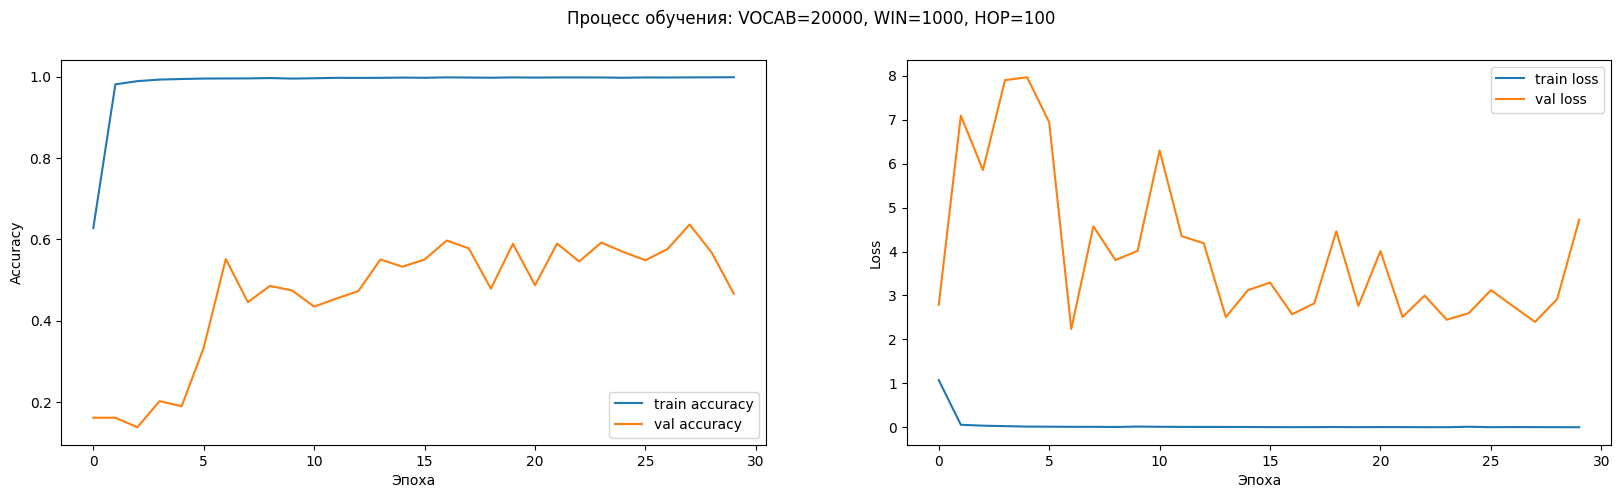

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


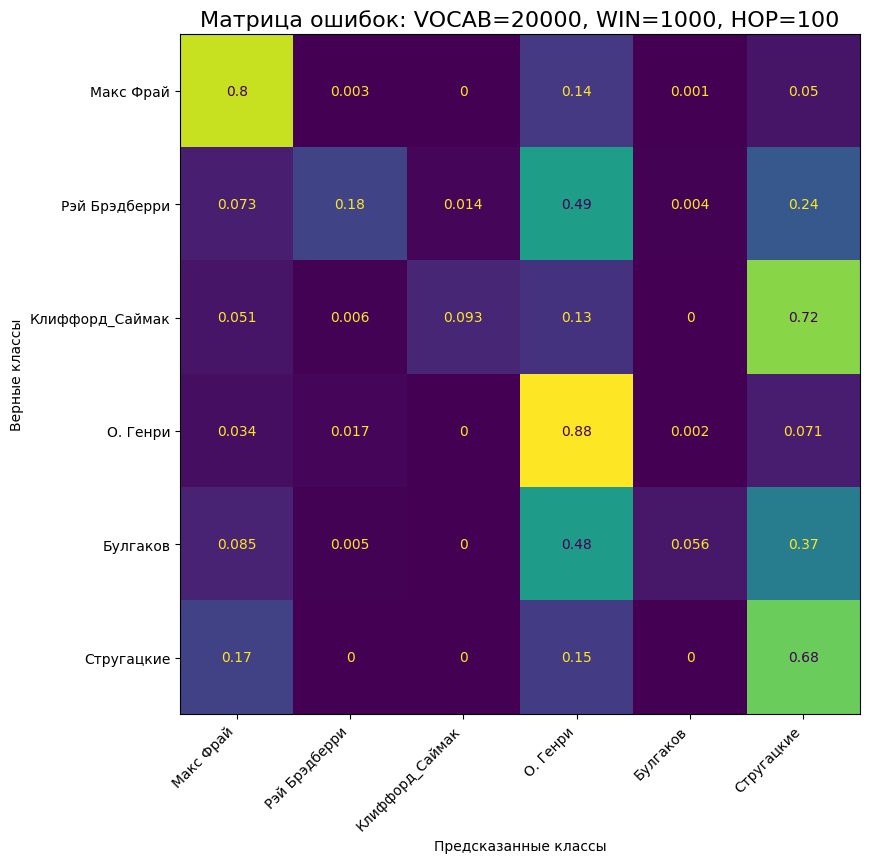


--- Результат "VOCAB=20000, WIN=1000, HOP=100" ---
  Класс: Макс Фрай             80% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         49% → О. Генри             - НЕВЕРНО
  Класс: Клиффорд_Саймак       72% → Стругацкие           - НЕВЕРНО
  Класс: О. Генри              88% → О. Генри             - ВЕРНО
  Класс: Булгаков              48% → О. Генри             - НЕВЕРНО
  Класс: Стругацкие            68% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 44.7%


In [12]:
# === Эксперимент 1: VOCAB=20000, WIN=1000, HOP=100 (базовая конфигурация) ===
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=20000, win_size=1000, win_hop=100)
model = build_best_model(vocab_size=20000, win_size=1000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=20000, WIN=1000, HOP=100', epochs=30)
res['vocab'] = 20000; res['win'] = 1000; res['hop'] = 100
results.append(res)

## 4. Эксперимент по влиянию размера словаря (`VOCAB_SIZE`)

Меняем `VOCAB_SIZE` на 5000, 10000, 40000. `WIN_SIZE = 1000`, `WIN_HOP = 100` — фиксированы.


=== Подготовка датасета: VOCAB_SIZE=5000, WIN_SIZE=1000, WIN_HOP=100 ===
Размер обучающей выборки: (17640, 1000), размер тестовой выборки: (6686, 1000)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 37s 309ms/step - accuracy: 0.5528 - loss: 1.2801 - val_accuracy: 0.1611 - val_loss: 2.3591
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.9426 - loss: 0.1711 - val_accuracy: 0.1971 - val_loss: 4.5060
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.9773 - loss: 0.0709 - val_accuracy: 0.1971 - val_loss: 6.9199
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 19s 212ms/step - accuracy: 0.9862 - loss: 0.0469 - val_accuracy: 0.1971 - val_loss: 10.4089
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.9897 - loss: 0.0357 - val_accuracy: 0.2161 - val_loss: 8.4429
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 19s 209ms/step - accuracy: 0.9936 - loss: 0.0215 - val_accuracy: 0.3558 - val_loss: 5.8963
Epoch 7/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.9930 - loss: 0.0277 - val_accuracy: 0.4729 - val_loss: 2.7253
Epoch 8/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.9948 - loss: 0.0155 - val_acc

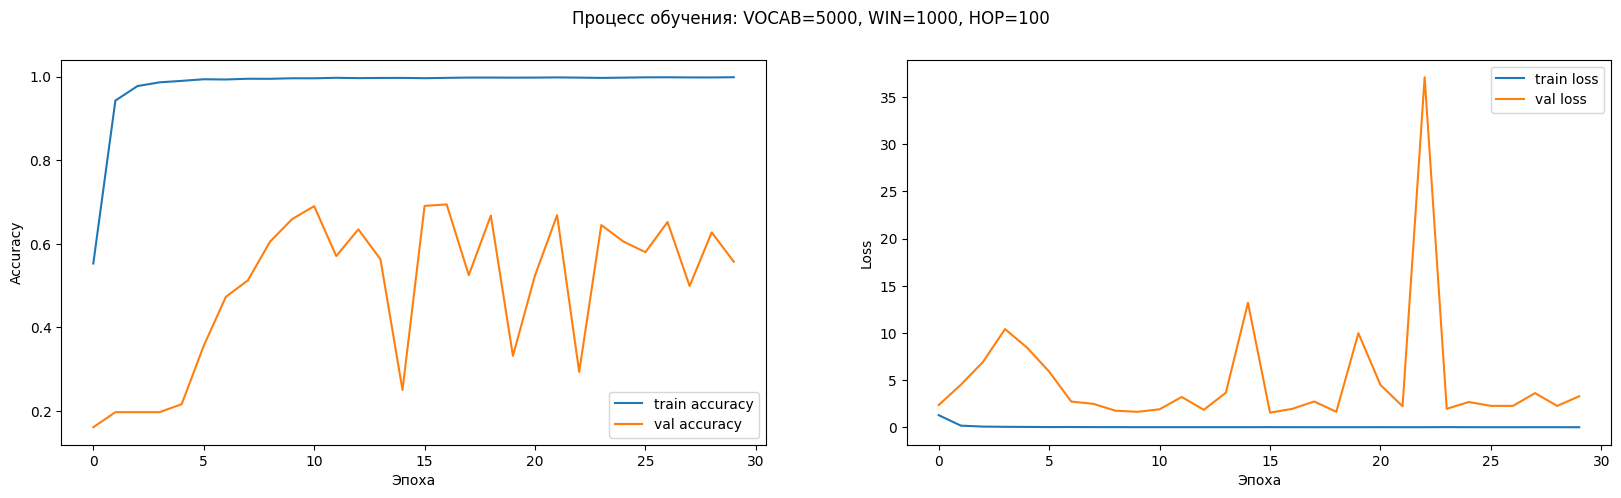

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


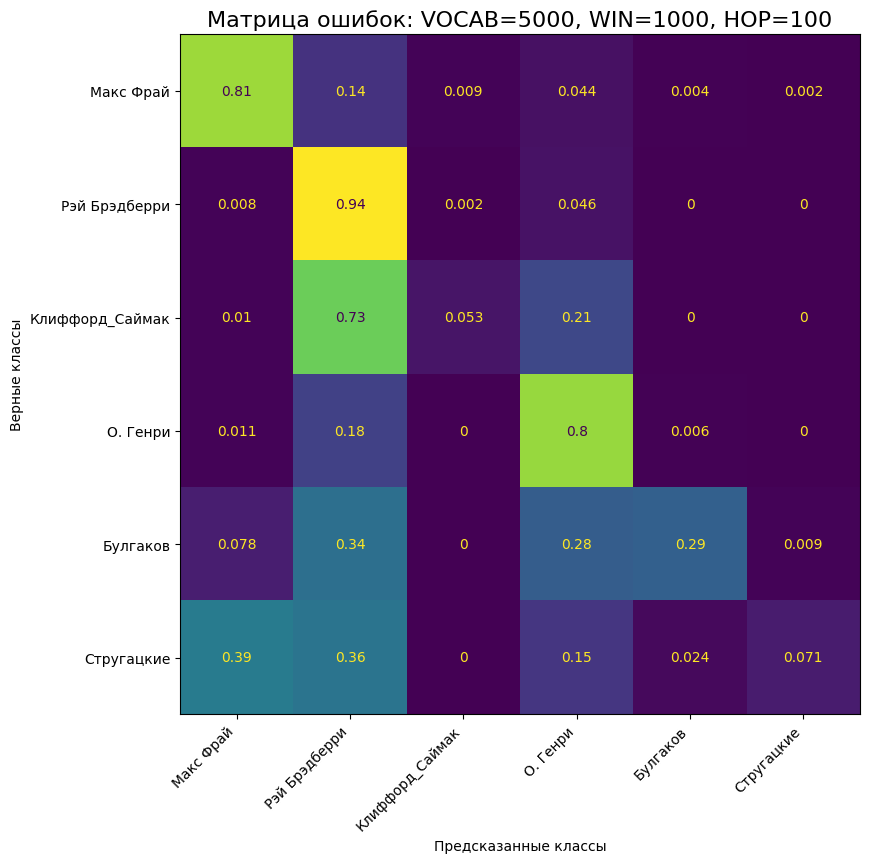


--- Результат "VOCAB=5000, WIN=1000, HOP=100" ---
  Класс: Макс Фрай             80% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         94% → Рэй Брэдберри        - ВЕРНО
  Класс: Клиффорд_Саймак       73% → Рэй Брэдберри        - НЕВЕРНО
  Класс: О. Генри              80% → О. Генри             - ВЕРНО
  Класс: Булгаков              34% → Рэй Брэдберри        - НЕВЕРНО
  Класс: Стругацкие            39% → Макс Фрай            - НЕВЕРНО

Средняя точность распознавания: 49.4%


In [13]:
# === Эксперимент 2: VOCAB=5000 ===
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=5000, win_size=1000, win_hop=100)
model = build_best_model(vocab_size=5000, win_size=1000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=5000, WIN=1000, HOP=100', epochs=30)
res['vocab'] = 5000; res['win'] = 1000; res['hop'] = 100
results.append(res)


=== Подготовка датасета: VOCAB_SIZE=10000, WIN_SIZE=1000, WIN_HOP=100 ===
Размер обучающей выборки: (17640, 1000), размер тестовой выборки: (6686, 1000)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 27s 219ms/step - accuracy: 0.5561 - loss: 1.2764 - val_accuracy: 0.2929 - val_loss: 2.0611
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.9587 - loss: 0.1212 - val_accuracy: 0.1817 - val_loss: 2.1622
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 150ms/step - accuracy: 0.9879 - loss: 0.0400 - val_accuracy: 0.3163 - val_loss: 3.3348
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.9917 - loss: 0.0271 - val_accuracy: 0.3845 - val_loss: 3.2364
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.9935 - loss: 0.0200 - val_accuracy: 0.5377 - val_loss: 2.7029
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.9944 - loss: 0.0198 - val_accuracy: 0.3491 - val_loss: 5.6006
Epoch 7/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.9942 - loss: 0.0201 - val_accuracy: 0.3697 - val_loss: 4.1319
Epoch 8/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.9946 - loss: 0.0182 - val_accu

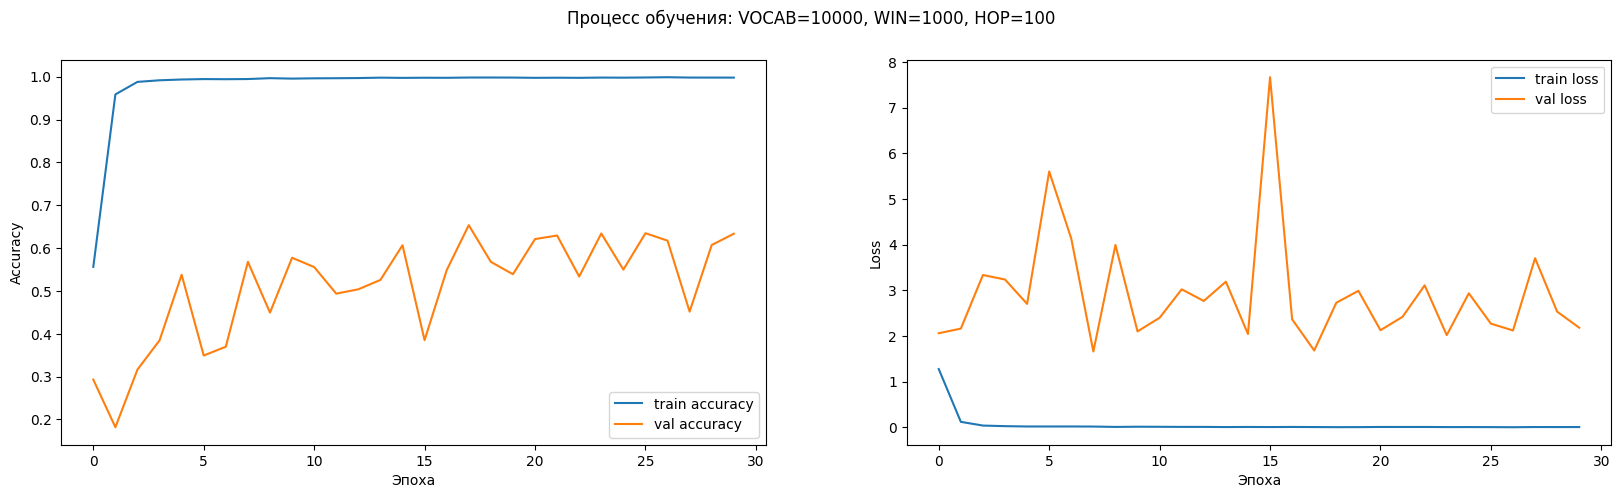

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


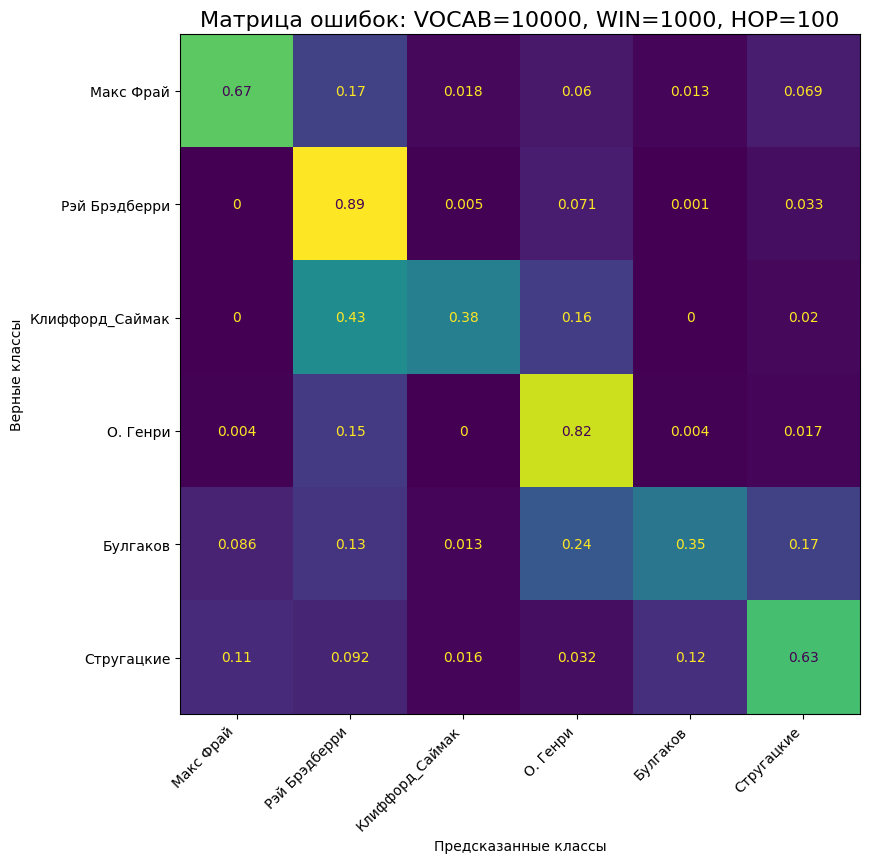


--- Результат "VOCAB=10000, WIN=1000, HOP=100" ---
  Класс: Макс Фрай             67% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         89% → Рэй Брэдберри        - ВЕРНО
  Класс: Клиффорд_Саймак       44% → Рэй Брэдберри        - НЕВЕРНО
  Класс: О. Генри              82% → О. Генри             - ВЕРНО
  Класс: Булгаков              35% → Булгаков             - ВЕРНО
  Класс: Стругацкие            63% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 62.4%


In [14]:
# === Эксперимент 3: VOCAB=10000 ===
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=10000, win_size=1000, win_hop=100)
model = build_best_model(vocab_size=10000, win_size=1000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=10000, WIN=1000, HOP=100', epochs=30)
res['vocab'] = 10000; res['win'] = 1000; res['hop'] = 100
results.append(res)


=== Подготовка датасета: VOCAB_SIZE=40000, WIN_SIZE=1000, WIN_HOP=100 ===
Размер обучающей выборки: (17640, 1000), размер тестовой выборки: (6686, 1000)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.6324 - loss: 1.0462 - val_accuracy: 0.2988 - val_loss: 2.7901
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9836 - loss: 0.0549 - val_accuracy: 0.0782 - val_loss: 7.5965
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9910 - loss: 0.0303 - val_accuracy: 0.3359 - val_loss: 3.9050
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9952 - loss: 0.0153 - val_accuracy: 0.1805 - val_loss: 7.0570
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.2798 - val_loss: 4.2693
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9954 - loss: 0.0145 - val_accuracy: 0.4176 - val_loss: 3.0698
Epoch 7/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9958 - loss: 0.0143 - val_accuracy: 0.4276 - val_loss: 4.3706
Epoch 8/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9963 - loss: 0.0105 - val_accuracy: 0.4305 -

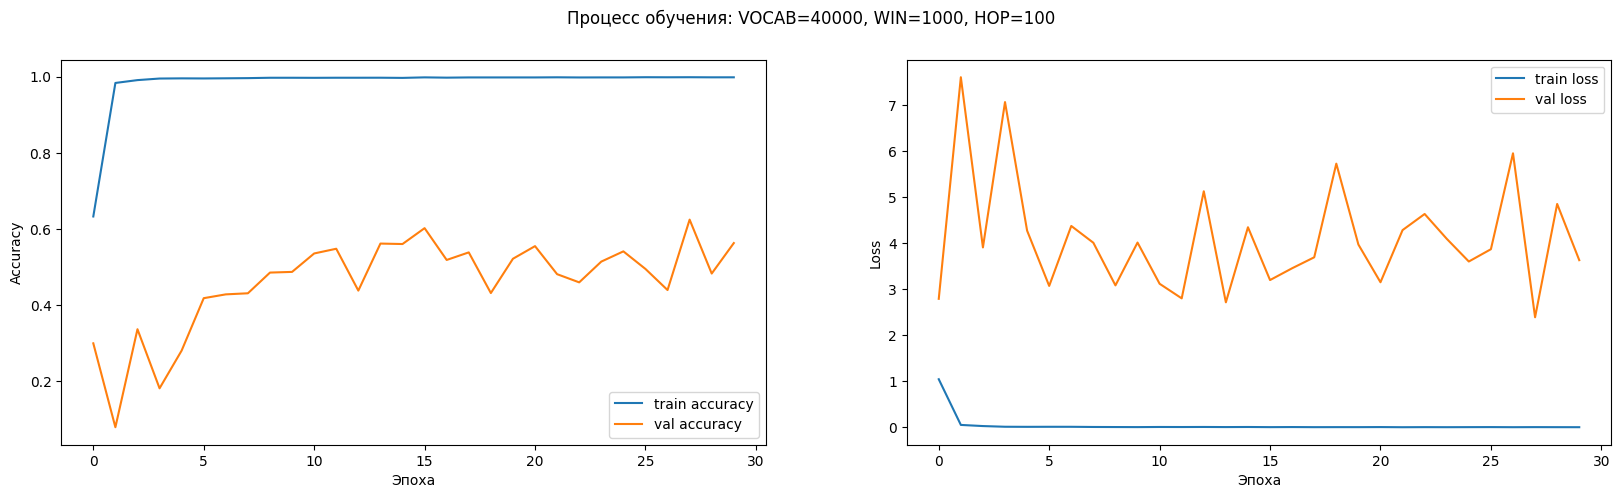

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


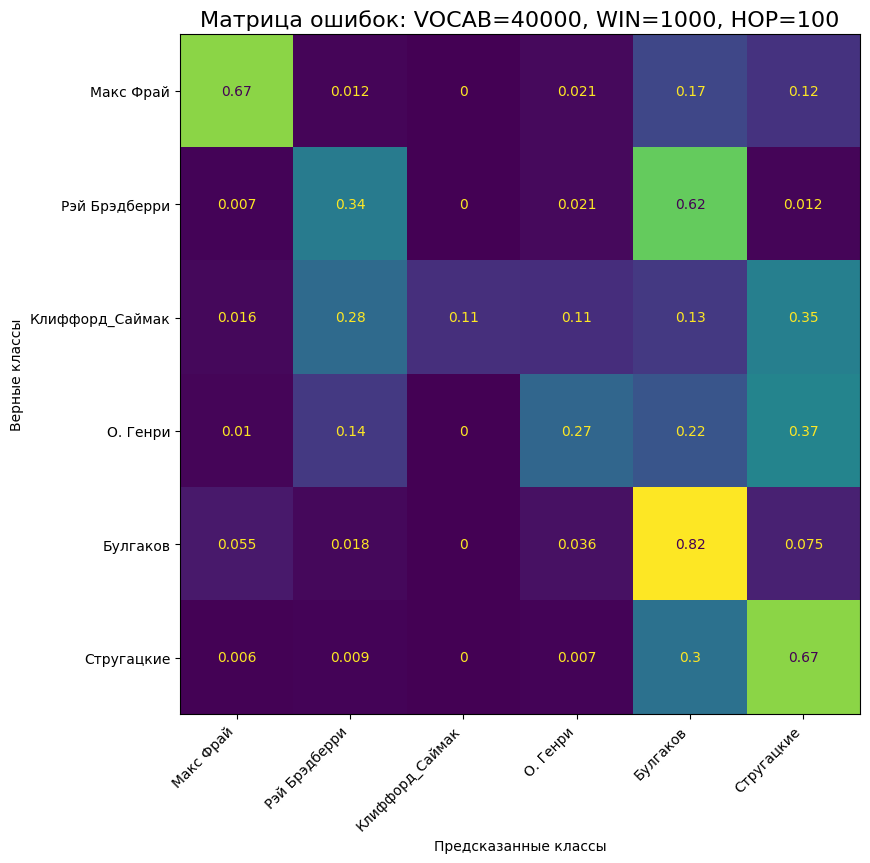


--- Результат "VOCAB=40000, WIN=1000, HOP=100" ---
  Класс: Макс Фрай             67% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         62% → Булгаков             - НЕВЕРНО
  Класс: Клиффорд_Саймак       35% → Стругацкие           - НЕВЕРНО
  Класс: О. Генри              37% → Стругацкие           - НЕВЕРНО
  Класс: Булгаков              82% → Булгаков             - ВЕРНО
  Класс: Стругацкие            67% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 48.0%


In [15]:
# === Эксперимент 4: VOCAB=40000 ===
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=40000, win_size=1000, win_hop=100)
model = build_best_model(vocab_size=40000, win_size=1000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=40000, WIN=1000, HOP=100', epochs=30)
res['vocab'] = 40000; res['win'] = 1000; res['hop'] = 100
results.append(res)

## 5. Эксперимент по влиянию длины окна (`WIN_SIZE`, `WIN_HOP`)

Меняем пары `(WIN_SIZE, WIN_HOP)`: `(500, 50)` и `(2000, 200)`. `VOCAB_SIZE = 20000` — фиксирован.


=== Подготовка датасета: VOCAB_SIZE=20000, WIN_SIZE=500, WIN_HOP=50 ===
Размер обучающей выборки: (35336, 500), размер тестовой выборки: (13427, 500)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 24s 90ms/step - accuracy: 0.7172 - loss: 0.7890 - val_accuracy: 0.1139 - val_loss: 3.5767
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9872 - loss: 0.0420 - val_accuracy: 0.3016 - val_loss: 4.2327
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9914 - loss: 0.0269 - val_accuracy: 0.4196 - val_loss: 2.6818
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.5694 - val_loss: 2.1644
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9957 - loss: 0.0155 - val_accuracy: 0.5295 - val_loss: 2.9659
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9956 - loss: 0.0145 - val_accuracy: 0.6269 - val_loss: 1.9345
Epoch 7/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9968 - loss: 0.0103 - val_accuracy: 0.5600 - val_loss: 3.2061
Epoch 8/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9969 - loss: 0.0114 - val_acc

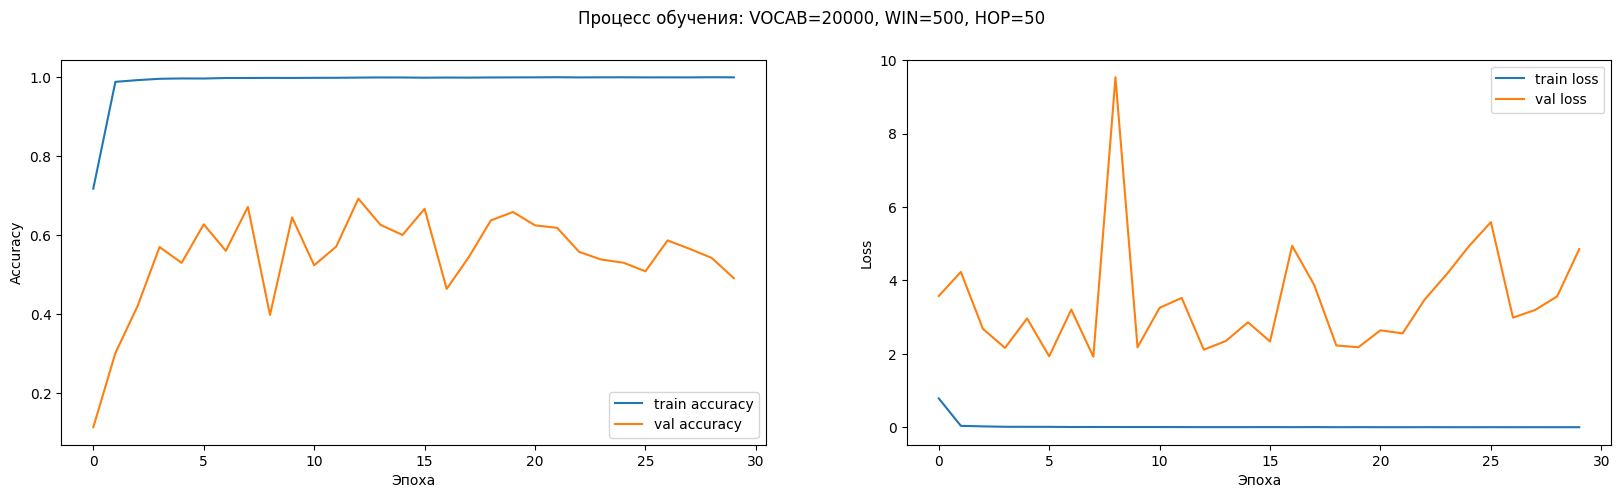

420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


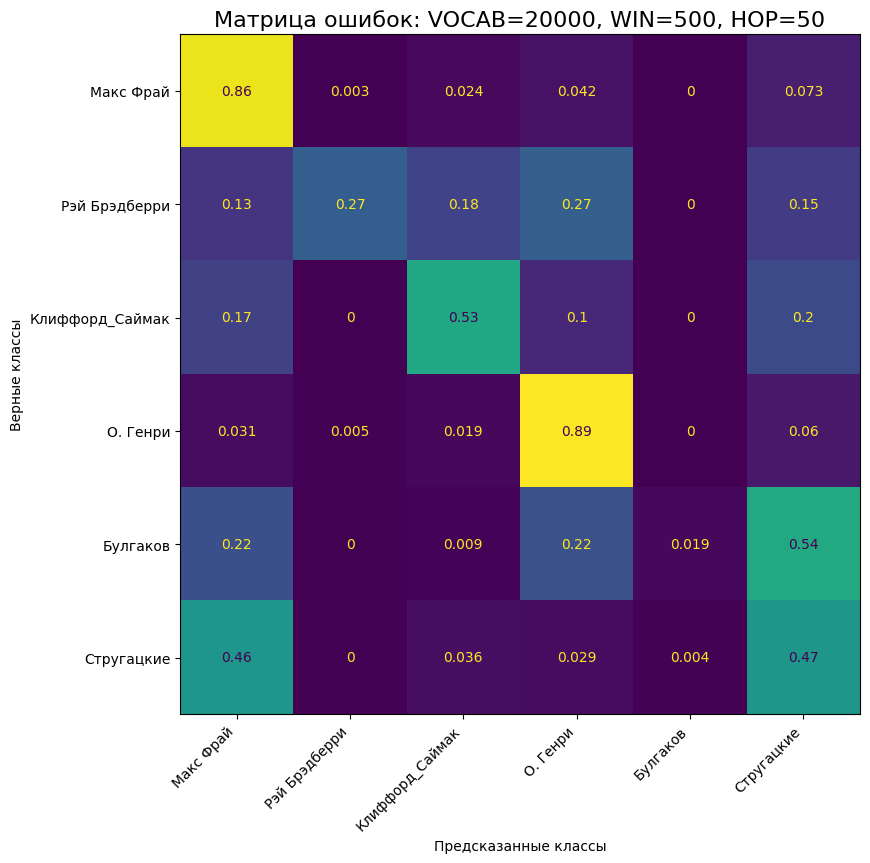


--- Результат "VOCAB=20000, WIN=500, HOP=50" ---
  Класс: Макс Фрай             86% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         27% → О. Генри             - НЕВЕРНО
  Класс: Клиффорд_Саймак       53% → Клиффорд_Саймак      - ВЕРНО
  Класс: О. Генри              88% → О. Генри             - ВЕРНО
  Класс: Булгаков              54% → Стругацкие           - НЕВЕРНО
  Класс: Стругацкие            47% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 50.4%


In [16]:
# === Эксперимент 5: WIN=500, HOP=50 ===
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=20000, win_size=500, win_hop=50)
model = build_best_model(vocab_size=20000, win_size=500)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=20000, WIN=500, HOP=50', epochs=30)
res['vocab'] = 20000; res['win'] = 500; res['hop'] = 50
results.append(res)


=== Подготовка датасета: VOCAB_SIZE=20000, WIN_SIZE=2000, WIN_HOP=200 ===
Размер обучающей выборки: (8792, 2000), размер тестовой выборки: (3314, 2000)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 404ms/step - accuracy: 0.5641 - loss: 1.2953 - val_accuracy: 0.1970 - val_loss: 1.9554
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - accuracy: 0.9675 - loss: 0.1008 - val_accuracy: 0.1970 - val_loss: 2.0398
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - accuracy: 0.9816 - loss: 0.0586 - val_accuracy: 0.1970 - val_loss: 3.4487
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.9911 - loss: 0.0310 - val_accuracy: 0.2571 - val_loss: 2.4265
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.9940 - loss: 0.0189 - val_accuracy: 0.1973 - val_loss: 2.3388
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 188ms/step - accuracy: 0.9923 - loss: 0.0222 - val_accuracy: 0.1973 - val_loss: 5.1567
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.9960 - loss: 0.0159 - val_accuracy: 0.2001 - val_loss: 5.2212
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - accuracy: 0.9926 - loss: 0.0263 - val_accuracy: 0

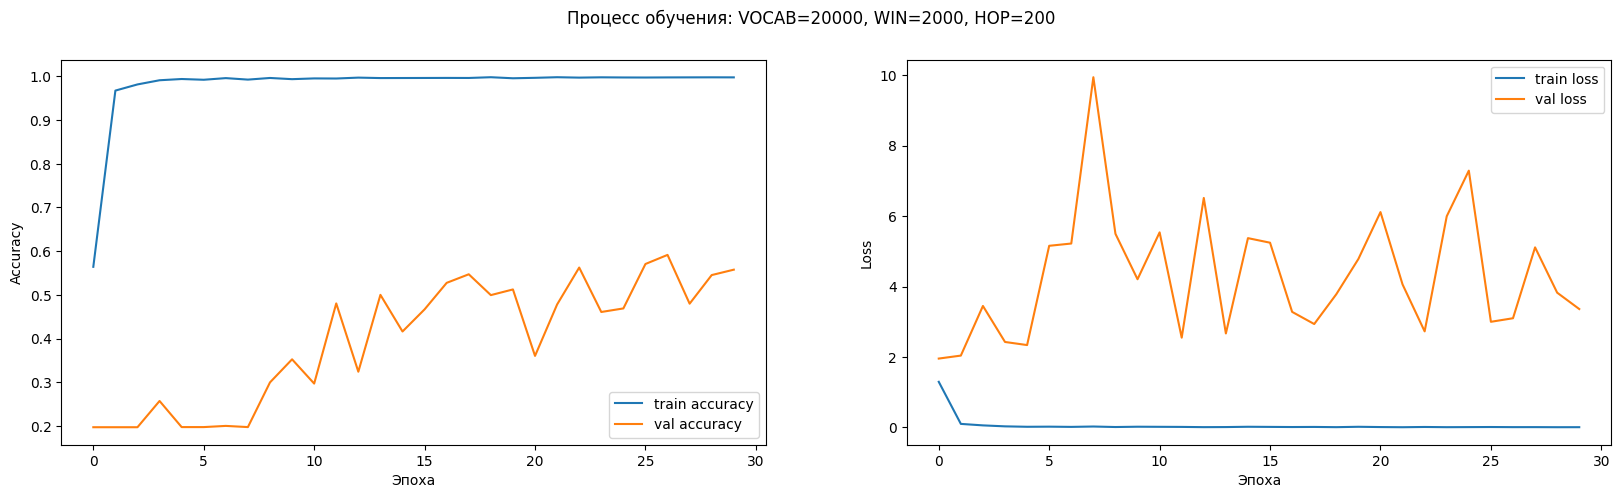

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


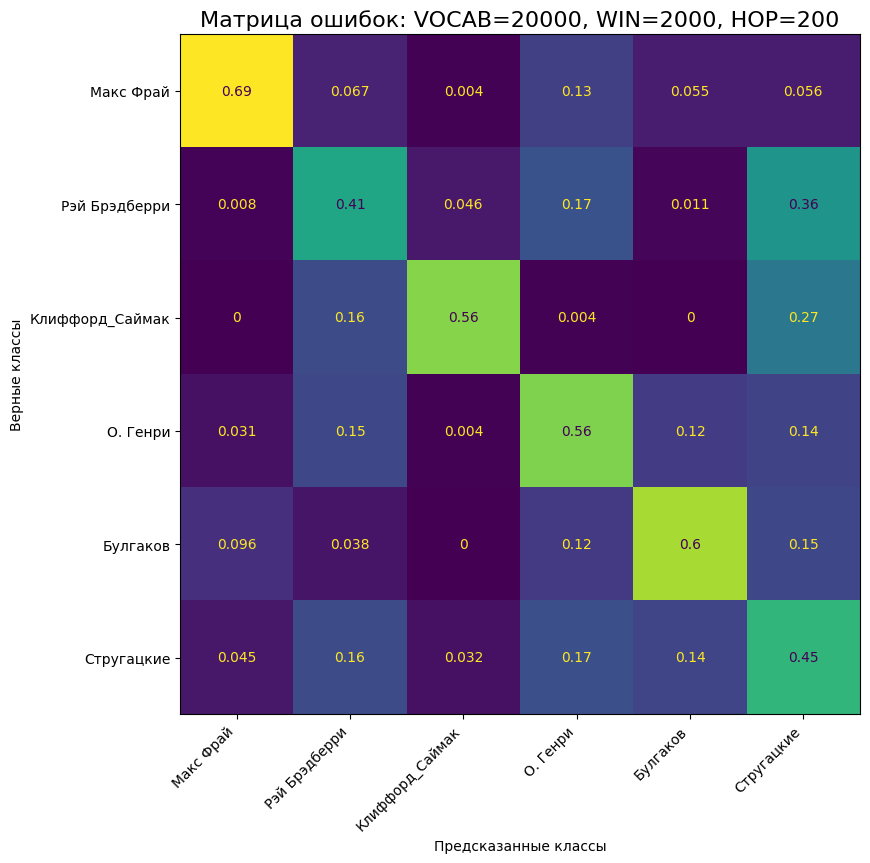


--- Результат "VOCAB=20000, WIN=2000, HOP=200" ---
  Класс: Макс Фрай             69% → Макс Фрай            - ВЕРНО
  Класс: Рэй Брэдберри         41% → Рэй Брэдберри        - ВЕРНО
  Класс: Клиффорд_Саймак       56% → Клиффорд_Саймак      - ВЕРНО
  Класс: О. Генри              56% → О. Генри             - ВЕРНО
  Класс: Булгаков              60% → Булгаков             - ВЕРНО
  Класс: Стругацкие            45% → Стругацкие           - ВЕРНО

Средняя точность распознавания: 54.4%


In [17]:
# === Эксперимент 6: WIN=2000, HOP=200 ===
x_train, y_train, x_test, y_test = prepare_dataset(vocab_size=20000, win_size=2000, win_hop=200)
model = build_best_model(vocab_size=20000, win_size=2000)
res = train_and_evaluate(model, x_train, y_train, x_test, y_test,
                         title='VOCAB=20000, WIN=2000, HOP=200', epochs=30)
res['vocab'] = 20000; res['win'] = 2000; res['hop'] = 200
results.append(res)

## 6. Сводная таблица результатов

In [19]:
# Сводная таблица всех экспериментов
import pandas as pd

df = pd.DataFrame(results)
df = df[['vocab', 'win', 'hop', 'mean_acc', 'best_val_acc', 'final_val_acc']]
df.columns = ['VOCAB_SIZE', 'WIN_SIZE', 'WIN_HOP', 'Средняя точность (по матрице)', 'Лучшая val_accuracy', 'Финальная val_accuracy']

# Преобразуем в проценты
for col in ['Средняя точность (по матрице)', 'Лучшая val_accuracy', 'Финальная val_accuracy']:
    df[col] = (df[col] * 100).round(1).astype(str) + '%'

print('\nСВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
display(df)


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ


,VOCAB_SIZE,WIN_SIZE,WIN_HOP,Средняя точность (по матрице),Лучшая val_accuracy,Финальная val_accuracy
0,20000,1000,100,44.7%,63.6%,46.6%
1,5000,1000,100,49.4%,69.4%,55.7%
2,10000,1000,100,62.4%,65.3%,63.3%
3,40000,1000,100,48.0%,62.4%,56.3%
4,20000,500,50,50.4%,69.2%,49.1%
5,20000,2000,200,54.4%,59.1%,55.8%
